# Broadcasting and workflow functions

*If you haven't read [Getting Started](../tutorials/getting_started.ipynb)
or [Distribution basics](01_distributions.ipynb), read those first.*

Every op in ProbPipe — `sample`, `log_prob`, `mean`, `condition_on`,
... — is a `@workflow_function` under the hood. This notebook
explains the mechanism: automatic uncertainty propagation when a
`Distribution` is passed where a concrete value is expected,
component-grouping for correlation preservation via `select()`
splatting, seeded reproducibility, orchestration hints, and the
`jax` vs `loop` vectorization auto-detection.

Contents:

1. Basic broadcasting — `Distribution` in, `Distribution` out.
2. Multiple and mixed arguments.
3. `EmpiricalDistribution` enumeration and budget-aware cutoff.
4. Vectorization: `jax` vs `loop`, `auto` detection.
5. Multivariate broadcasting.
6. Seed management.
7. Non-numeric results.
8. Provenance tracking.
9. External distributions via the converter registry.


In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt


from probpipe import Normal, MultivariateNormal, EmpiricalDistribution, BroadcastDistribution, provenance_ancestors
from probpipe.core.node import WorkflowFunction, workflow_function
from probpipe import expectation, log_prob, mean, prob, sample
from probpipe import WorkflowKind, prefect_config

key = jax.random.PRNGKey(0)
# This notebook is about distributions, not Prefect — disable orchestration
prefect_config.workflow_kind = WorkflowKind.OFF

## Basic Broadcasting

When a function's type hint expects `jnp.ndarray` but the caller passes a `Normal` (or any `Distribution`), the `WorkflowFunction` detects the mismatch and **broadcasts** automatically: it draws `n_broadcast_samples` from the distribution, calls the function once per sample, and returns the output distribution directly. `n_broadcast_samples` can be set at construction or overridden at call time.

> **Note:** The wrapped function must not have parameters named `n_broadcast_samples`, `seed`, or `include_inputs` — these names are reserved by `WorkflowFunction` for call-time overrides and will raise a `ValueError` at construction time.

In [2]:
@workflow_function
def double_it(x: jnp.ndarray) -> jnp.ndarray:
    return x * 2

g = Normal(loc=3.0, scale=1.0, name="auto_d1")
# override default value of n_broadcast_samples=128
result = double_it(g, n_broadcast_samples=1_000)

print(f"Input: Normal(loc=3, scale=1)")
print(f"Output type: {type(result).__name__} with {result.n} samples")
print(f"Output mean ≈ {float(jnp.mean(result.samples)):.3f} (expected ≈ 6.0)")

Input: Normal(loc=3, scale=1)
Output type: _RecordMarginal with 1000 samples
Output mean ≈ 5.960 (expected ≈ 6.0)


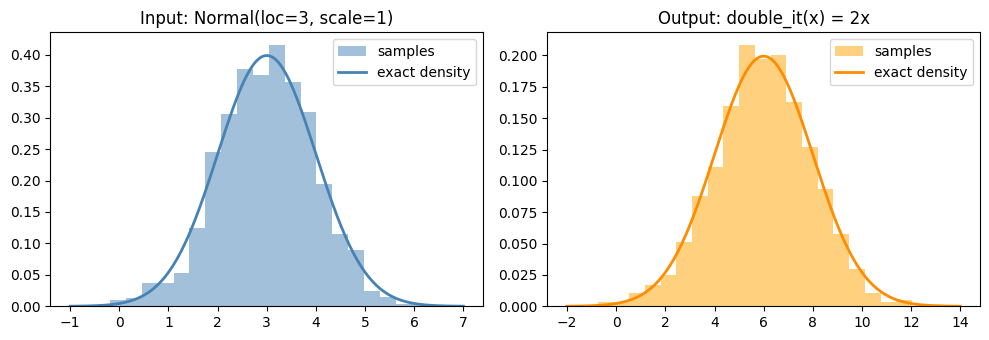

In [3]:
# Plot input vs output distributions with density overlays
input_samples = sample(g, sample_shape=(1_000,), key=jax.random.PRNGKey(39))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))

# Input histogram + exact density
xs_in = np.linspace(-1, 7, 200)
input_density = jax.vmap(lambda v: jnp.exp(g._log_prob(v)))(jnp.array(xs_in))
ax1.hist(np.array(input_samples), bins=20, density=True, alpha=0.5, color="steelblue", label="samples")
ax1.plot(xs_in, np.array(input_density), color="steelblue", linewidth=2, label="exact density")
ax1.set_title("Input: Normal(loc=3, scale=1)")
ax1.legend()

# Output histogram + exact density (Normal(6, 2, name="auto_d1") since doubling scales loc and scale)
xs_out = np.linspace(-2, 14, 200)
output_dist = Normal(loc=6.0, scale=2.0, name="auto_d2")
output_density = jax.vmap(lambda v: jnp.exp(output_dist._log_prob(v)))(jnp.array(xs_out))
ax2.hist(np.array(result.samples), bins=20, density=True, alpha=0.5, color="orange", label="samples")
ax2.plot(xs_out, np.array(output_density), color="darkorange", linewidth=2, label="exact density")
ax2.set_title("Output: double_it(x) = 2x")
ax2.legend()

plt.tight_layout()
plt.show()

The output marginal supports `expectation()`, which computes an exact weighted sum. To disable error tracking on parametric distributions, pass `return_dist=False`.

In [4]:
# Exact expectation on the broadcast result's output marginal
ex_result = expectation(result, lambda x: x)
print(f"E[2X] from broadcast: {float(ex_result):.4f} (exact over samples)")

# For parametric distributions, use return_dist=False for a plain scalar
input_dist = Normal(loc=3.0, scale=1.0, name="auto_d3")
ex_plain = expectation(input_dist, lambda x: 2*x, key=jax.random.PRNGKey(99),
return_dist=False)
print(f"E[2X] from Normal:    {float(ex_plain):.4f} (MC point estimate)")

E[2X] from broadcast: 5.9600 (exact over samples)
E[2X] from Normal:    5.9240 (MC point estimate)


## Multiple Distribution Arguments

When multiple arguments receive distributions, each is sampled independently per call. The i-th call uses the i-th sample from every distribution argument.

In [5]:
@workflow_function(n_broadcast_samples=500, vectorize="loop")
def weighted_sum(a: jnp.ndarray, b: jnp.ndarray) -> jnp.ndarray:
    return 0.7 * a + 0.3 * b

result = weighted_sum(Normal(loc=10.0, scale=1.0, name="auto_d4"), Normal(loc=0.0, scale=2.0, name="auto_d5"))
print(f"Number of samples: {result.n}")
print(f"Output dimension: {result.dim}")
print(f"Mean ≈ {float(jnp.mean(result.samples)):.3f} (expected ≈ 7.0)")
print(f"Std  ≈ {float(jnp.std(result.samples)):.3f} (expected ≈ {(0.7**2 + (0.3*2)**2)**0.5:.3f})")

Number of samples: 500
Output dimension: 1
Mean ≈ 7.075 (expected ≈ 7.0)
Std  ≈ 0.912 (expected ≈ 0.922)


Note how the default value of `n_broadcast_samples` is set to 500 in the `@workflow_function` decorator. Hence, `result` is an `EmpiricalDistribution` of 500 samples.

## Mixed Distribution and Concrete Arguments

Only distribution arguments are broadcast; concrete values (floats, arrays) pass through unchanged to every function call.

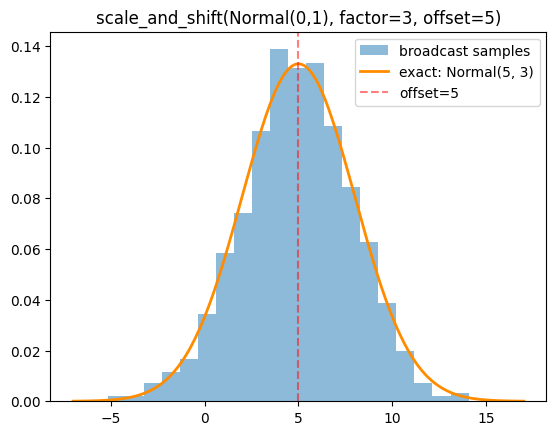

In [6]:
@workflow_function
def scale_and_shift(x: jnp.ndarray, factor: float, offset: float) -> jnp.ndarray:
    return x * factor + offset

result = scale_and_shift(Normal(loc=0.0, scale=1.0, name="auto_d6"), 3.0, 5.0, n_broadcast_samples=1_000)
# Exact output distribution: Normal(loc=0*3+5=5, scale=1*3=3, name="auto_d2")
exact = Normal(loc=5.0, scale=3.0, name="auto_d7")
xs = np.linspace(-7, 17, 200)
exact_density = jax.vmap(lambda v: prob(exact, v))(jnp.array(xs))

plt.hist(np.array(result.samples), bins=20, density=True, alpha=0.5, label="broadcast samples")
plt.plot(xs, np.array(exact_density), color="darkorange", linewidth=2, label="exact: Normal(5, 3)")
plt.axvline(5.0, color="red", linestyle="--", alpha=0.5, label="offset=5")
plt.title("scale_and_shift(Normal(0,1), factor=3, offset=5)")
plt.legend()
plt.show()

## EmpiricalDistribution Enumeration

When an `EmpiricalDistribution` with support less than `n_broadcast_samples`, the workflow **enumerates** all samples instead of resampling. Weights are propagated exactly, so no information is lost.

In [7]:
def identity(x):
    return x

samples = jnp.array([[1.0], [2.0], [3.0]])
weights = jnp.array([0.2, 0.3, 0.5])
ed = EmpiricalDistribution(samples, weights, name="x")

w = WorkflowFunction(func=identity, n_broadcast_samples=100, vectorize="loop")
result = w(ed)

print(f"Input: {ed.n} weighted samples")
print(f"Output: {result.n} samples (enumerated, not resampled to 100)")
print(f"Weights preserved: {np.allclose(result.weights, weights, atol=1e-5)}")

Input: 3 weighted samples
Output: 3 samples (enumerated, not resampled to 100)
Weights preserved: True


## Cartesian Product of Multiple Empirical Distributions

With two empirical distributions, the workflow forms the **cartesian product** of their samples and multiplies weights.

In [8]:
@workflow_function(vectorize="loop")
def add_them(a: jnp.ndarray, b: jnp.ndarray) -> jnp.ndarray:
    return a + b

ed1 = EmpiricalDistribution(jnp.array([[1.0], [2.0]]), name="a")
ed2 = EmpiricalDistribution(jnp.array([[10.0], [20.0], [30.0]]), name="b")

result = add_them(ed1, ed2)
print(f"Cartesian product: {ed1.n} × {ed2.n} = {result.n} evaluations")
print(f"Results: {np.asarray(result.samples).ravel()}")
print(f"Weights: {result.weights}")

Cartesian product: 2 × 3 = 6 evaluations
Results: [11. 21. 31. 12. 22. 32.]
Weights: [0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]


## Budget-Aware Greedy Cutoff

When the cartesian product of all empirical distributions would exceed `n_broadcast_samples`, the workflow uses a **greedy strategy**: it enumerates the smallest empiricals first (sorted by size) and samples from the rest. This keeps total evaluations within budget while preserving as much exact enumeration as possible.

In [9]:
@workflow_function(n_broadcast_samples=50, vectorize="loop")
def sum_three(a: jnp.ndarray, b: jnp.ndarray, c: jnp.ndarray) -> jnp.ndarray:
    return a + b + c

ed_small = EmpiricalDistribution(jnp.array([[1.0], [2.0]]), name="a")          # n=2
ed_medium = EmpiricalDistribution(jnp.arange(5).reshape(-1, 1).astype(jnp.float32), name="b")  # n=5
ed_large = EmpiricalDistribution(jnp.arange(20).reshape(-1, 1).astype(jnp.float32), name="c")  # n=20

result = sum_three(ed_small, ed_medium, ed_large)

print(f"Full product: {ed_small.n}\u00d7{ed_medium.n}\u00d7{ed_large.n} = {ed_small.n*ed_medium.n*ed_large.n}")
print(f"Budget: 50")
print(f"Enumerated: {ed_small.n}\u00d7{ed_medium.n} = 10 combos")
print(f"Sampled: {50//10} draws from ed_large per combo")
print(f"Total evaluations: {result.n}")

Full product: 2×5×20 = 200
Budget: 50
Enumerated: 2×5 = 10 combos
Sampled: 5 draws from ed_large per combo
Total evaluations: 50


## JAX vmap Backend

The `"jax"` vectorization strategy uses `jax.vmap` to vectorize the function over all samples at once, which is much faster for JAX-traceable functions. It draws all samples up front and applies the function in a single vectorized call.

In [10]:
import time

def transform(x: jnp.ndarray) -> jnp.ndarray:
    return jnp.sin(x) ** 2 + jnp.cos(x)

g = Normal(loc=0.0, scale=1.0, name="auto_d9")

# Loop vectorization
w_loop = WorkflowFunction(func=transform, n_broadcast_samples=5000, vectorize="loop")
t0 = time.perf_counter()
r_loop = w_loop(g)
t_loop = time.perf_counter() - t0

# JAX vectorization
w_jax = WorkflowFunction(func=transform, n_broadcast_samples=5000, vectorize="jax")
t0 = time.perf_counter()
r_jax = w_jax(g)
t_jax = time.perf_counter() - t0

print(f"Loop vectorize: {t_loop:.3f}s ({r_loop.n} samples)")
print(f"JAX  vectorize: {t_jax:.3f}s ({r_jax.n} samples)")
print(f"Speedup: {t_loop/t_jax:.1f}x")

Loop vectorize: 0.827s (5000 samples)
JAX  vectorize: 0.076s (5000 samples)
Speedup: 10.8x


## Auto Backend Detection

The default `"auto"` vectorization mode probes the function with `jax.make_jaxpr`. If the function is JAX-traceable, it selects `"jax"` (vmap); otherwise it falls back to `"loop"`.

In [11]:
import scipy.special

# JAX-traceable -> auto selects "jax"
@workflow_function(n_broadcast_samples=50)
def jax_fn(x: jnp.ndarray) -> jnp.ndarray:
    return jnp.exp(-x**2)

_ = jax_fn(Normal(loc=0.0, scale=1.0, name="auto_d10"))
print(f"jax_fn \u2192 vectorize: {jax_fn._resolved_vectorize}")

# Non-JAX -> auto selects "loop"
@workflow_function(n_broadcast_samples=50)
def scipy_fn(x: jnp.ndarray) -> jnp.ndarray:
    return jnp.asarray(scipy.special.gamma(np.asarray(x)))

_ = scipy_fn(Normal(loc=2.0, scale=0.1, name="auto_d11"))
print(f"scipy_fn \u2192 vectorize: {scipy_fn._resolved_vectorize}")

jax_fn → vectorize: jax
scipy_fn → vectorize: loop


## Multivariate Broadcasting

Broadcasting works with multivariate distributions too. Each sample is a vector, and the function receives one vector per call (or a batch of vectors with `"jax"` vectorization).

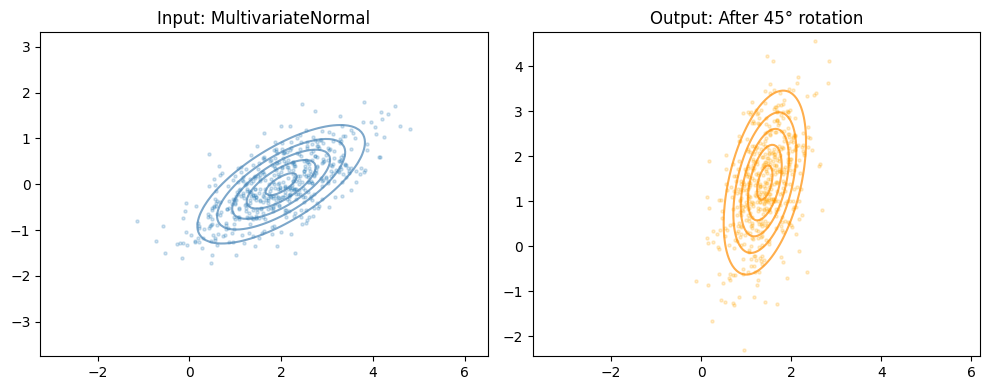

In [12]:
@workflow_function(n_broadcast_samples=500, vectorize="jax")
def project_2d(x: jnp.ndarray) -> jnp.ndarray:
    """Rotate a 2D vector by 45 degrees."""
    theta = jnp.pi / 4
    R = jnp.array([[jnp.cos(theta), -jnp.sin(theta)],
                    [jnp.sin(theta),  jnp.cos(theta)]])
    return R @ x

mvn = MultivariateNormal(loc=jnp.array([2.0, 0.0]), cov=jnp.array([[1.0, 0.5], [0.5, 0.5]]), name="auto_d12")
result = project_2d(mvn)
# Compute exact output distribution: R @ loc, R @ cov @ R^T
theta = jnp.pi / 4
R = jnp.array([[jnp.cos(theta), -jnp.sin(theta)],
                [jnp.sin(theta),  jnp.cos(theta)]])
out_loc = R @ jnp.array([2.0, 0.0])
in_cov = jnp.array([[1.0, 0.5], [0.5, 0.5]])
out_cov = R @ in_cov @ R.T
mvn_out = MultivariateNormal(loc=out_loc, cov=out_cov, name="auto_d13")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Helper to draw contours for a 2D MVN
def draw_contours(ax, mvn_dist, color, n_grid=100):
    loc = np.array(mvn_dist.loc)
    samples_for_range = np.asarray(sample(mvn_dist, key=jax.random.PRNGKey(0), sample_shape=(500,)))
    x_range = np.linspace(float(samples_for_range[:, 0].min()) - 0.5,
                          float(samples_for_range[:, 0].max()) + 0.5, n_grid)
    y_range = np.linspace(float(samples_for_range[:, 1].min()) - 0.5,
                          float(samples_for_range[:, 1].max()) + 0.5, n_grid)
    X, Y = np.meshgrid(x_range, y_range)
    points = jnp.stack([X.ravel(), Y.ravel()], axis=-1)
    Z = jax.vmap(lambda v: jnp.asarray(log_prob(mvn_dist, v)))(points).reshape(X.shape)
    ax.contour(X, Y, np.exp(np.array(Z)), levels=5, colors=color, alpha=0.7, linewidths=1.5)

input_samples = np.asarray(sample(mvn, key=jax.random.PRNGKey(99), sample_shape=(500,)))
ax1.scatter(input_samples[:, 0], input_samples[:, 1], alpha=0.2, s=5)
draw_contours(ax1, mvn, "steelblue")
ax1.set_title("Input: MultivariateNormal")
ax1.axis("equal")

out_samples = np.asarray(result.samples)
ax2.scatter(out_samples[:, 0], out_samples[:, 1], alpha=0.2, s=5, color="orange")
draw_contours(ax2, mvn_out, "darkorange")
ax2.set_title("Output: After 45° rotation")
ax2.axis("equal")
plt.tight_layout()
plt.show()

## Seed Management

Different seeds produce different samples. Seeds can be set at construction or overridden at call time for reproducibility.

In [13]:
g = Normal(loc=0.0, scale=1.0, name="auto_d14")

w1 = WorkflowFunction(func=identity, n_broadcast_samples=10, vectorize="loop", seed=0)
w2 = WorkflowFunction(func=identity, n_broadcast_samples=10, vectorize="loop", seed=42)

r1 = w1(g)
r2 = w2(g)
s1 = np.asarray(r1.samples)
s2 = np.asarray(r2.samples)
print(f"Seed 0:  {s1[:5].ravel()}")
print(f"Seed 42: {s2[:5].ravel()}")
print(f"Same? {bool(jnp.allclose(s1, s2))}")

# Call-time override for reproducibility
w = WorkflowFunction(func=identity, n_broadcast_samples=10, vectorize="loop")
r_a = w(g, seed=99)
r_b = w(g, seed=99)
print(f"\nSame seed at call time: {bool(jnp.allclose(np.asarray(r_a.samples), np.asarray(r_b.samples)))}")

Seed 0:  [-1.335625   -0.35256302  0.30970404 -1.000946   -0.07749758]
Seed 42: [-1.0413289   0.52936333 -2.4925628   0.462306   -0.935199  ]
Same? False

Same seed at call time: True


## Non-Numeric Results

If the wrapped function returns non-numeric types (strings, dicts, etc.), broadcasting returns a `_ListMarginal` with no protocol support (no sampling or moments).

In [14]:
@workflow_function(n_broadcast_samples=5, vectorize="loop")
def describe(x: jnp.ndarray) -> str:
    return f"value={float(x):.3f}, positive={bool(x > 0)}"

result = describe(Normal(loc=0.0, scale=1.0, name="auto_d15"))
print(f"Return type: {type(result).__name__}")
for r in result.items:
    print(f"  {r}")

Return type: _ListMarginal
  value=-1.336, positive=False
  value=-0.353, positive=False
  value=0.310, positive=True
  value=-1.001, positive=False
  value=-0.077, positive=False


## Provenance Tracking

Every distribution produced by broadcasting records which distributions were propagated, which vectorization strategy was used, and the function name. This makes it easy to trace how an output distribution was derived.

In [15]:
# Broadcast result records its provenance
a = Normal(loc=1.0, scale=0.5, name='param_a')
b = Normal(loc=2.0, scale=1.0, name='param_b')

@workflow_function(n_broadcast_samples=100, vectorize='loop')
def multiply(x: jnp.ndarray, y: jnp.ndarray) -> jnp.ndarray:
    return x * y

result = multiply(a, b)

print(f'Source: {result.source}')
print(f'Operation:      {result.source.operation}')
print(f'Vectorize:      {result.source.metadata["vectorize"]}')
print(f'Function:       {result.source.metadata["func"]}')
print(f'Broadcast args: {result.source.metadata["broadcast_args"]}')
print(f'N samples:      {result.source.metadata["n_samples"]}')

# Trace ancestors — which distributions fed into this result?
ancestors = provenance_ancestors(result)
print(f'\nAncestors: {[anc.name for anc in ancestors]}')

# Serialization for logging/auditing
prov_dict = result.source.to_dict()
print(f'\nSerialized provenance:')
for k, v in prov_dict.items():
    print(f'  {k}: {v}')

Source: Provenance('broadcast', parents=[param_a, param_b])
Operation:      broadcast
Vectorize:      loop
Function:       multiply
Broadcast args: ['x', 'y']
N samples:      100

Ancestors: ['param_a', 'param_b']

Serialized provenance:
  operation: broadcast
  parents: [{'type': 'Normal', 'name': 'param_a'}, {'type': 'Normal', 'name': 'param_b'}]
  metadata: {'vectorize': 'loop', 'orchestrate': 'off', 'n_samples': 100, 'func': 'multiply', 'broadcast_args': ['x', 'y']}


## Broadcasting with External Distributions

WorkflowFunction automatically recognizes raw TFP and scipy.stats distributions via the converter registry. External distributions are converted to ProbPipe types before broadcasting, so existing workflows work seamlessly with distributions from any supported library.

In [16]:
import tensorflow_probability.substrates.jax.distributions as tfd
import scipy.stats as ss

# Create a simple workflow
@workflow_function()
def negate(x):
    return -x

# Use a raw TFP distribution as input -- auto-converted before broadcasting
result_tfp = negate(tfd.Normal(loc=3.0, scale=1.0, name="auto_d16"))
print(f"From tfd.Normal: mean={float(mean(result_tfp)):.2f}")

# Use a scipy distribution as input
result_scipy = negate(ss.norm(loc=3.0, scale=1.0))
print(f"From scipy.norm: mean={float(mean(result_scipy)):.2f}")

From tfd.Normal: mean=-3.02
From scipy.norm: mean=-3.06


## Summary

Key takeaways:

- **Broadcasting** automatically propagates uncertainty through any function wrapped in a `WorkflowFunction`, returning the output distribution directly.
- Pass `include_inputs=True` to get a `BroadcastDistribution` that preserves the joint over inputs and outputs (saves memory).
- **EmpiricalDistributions** with small support are **enumerated exactly** (weight propagation, no resampling).
- **Greedy budget-aware cutoff** prevents combinatorial explosion when multiple empiricals are combined.
- The **`"jax"` vectorization** uses `vmap` for fast vectorized execution of JAX-traceable functions.
- The **`"auto"` mode** intelligently selects `"jax"` or `"loop"` based on traceability.
- **Seeds** ensure reproducibility and can be set at construction or overridden at call time.